# Overlap with transposable elements

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cd = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/CaptureCMPRA/"
mpra_alus = pl.read_csv(cd+"results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_alus_OA.tsv", separator="\t")
mpra_repeats = pl.read_csv(cd+"results/MPRA_analysis/CMPRA5/labeled_data_promoteroa_repeat_families_OA.tsv", separator="\t")

In [3]:
mpra_repeats = mpra_repeats.filter(pl.col("promoter").is_null().not_()).with_columns(
	# Get unique, sorted OE_repeats
	pl.col("OE_repeats").str.split(",").list.unique().list.sort().list.join(",").alias("OE_repeats"),
	# Count occurrences of each OE_repeat
	pl.len().over("OE_repeats").alias("count")
)

In [ ]:
mpra_alus = mpra_alus.with_columns(
	pl.when((pl.col("promoter_alu") == "yes") & (pl.col("OE_alu") == "no")).then(pl.lit("alu in promoter"))
	.when((pl.col("OE_alu") == "yes") & (pl.col("promoter_alu") == "no")).then(pl.lit("alu in CRE"))
	.when((pl.col("OE_alu") == "yes") & (pl.col("promoter_alu") == "yes")).then(pl.lit("alu in promoter and CRE"))
	.otherwise(pl.lit("no alu")).alias("alu_location")
)

<Axes: xlabel='z_score', ylabel='Count'>

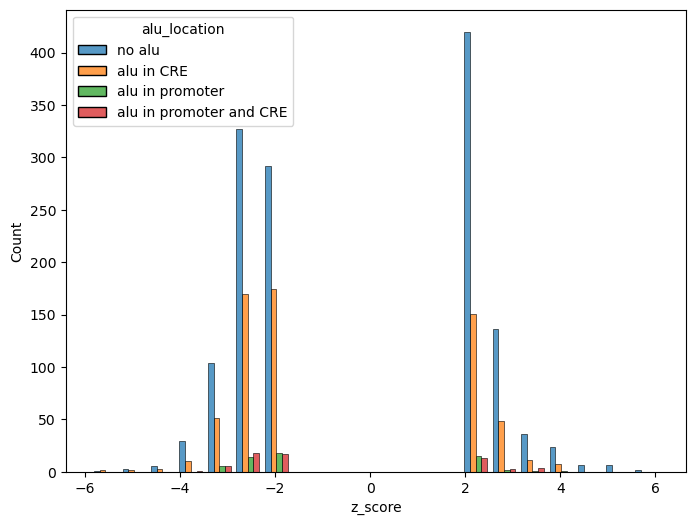

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.histplot(data=mpra_alus.filter(pl.col("effect")!="no effect").to_pandas(), x="z_score", hue="alu_location", bins=20, multiple="dodge", shrink=.8)

<Axes: xlabel='z_score', ylabel='Count'>

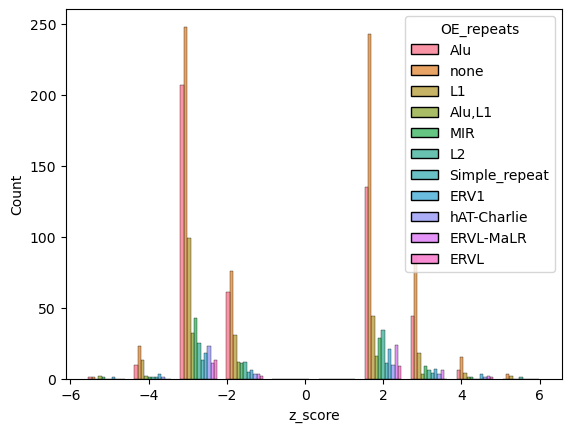

In [ ]:
sns.histplot(data=mpra_repeats.filter(pl.col("effect")!="no effect")
			 .filter(pl.col("count")> 500).to_pandas(), x="z_score", hue="OE_repeats", bins=10, multiple="dodge", shrink=.8)

In [ ]:
mpra_repeats.select(pl.col("OE_repeats"), pl.len().over("OE_repeats").alias("count")).unique().sort("count", descending=True)

OE_repeats,count
str,u32
"""none""",19831
"""Alu""",14452
"""L1""",4797
"""MIR""",2315
"""L2""",2216
…,…
"""Alu,L1,hAT?""",1
"""L1,RTE-X""",1
"""Alu,L2,hAT-Blackjack""",1


In [ ]:
mpra_repeats.filter(pl.col("effect")!="no effect") \
			.select("effect",pl.col("OE_repeats"), pl.len().over("OE_repeats","effect").alias("count")/pl.len().over("effect"))

effect,OE_repeats,count
str,str,f64
"""downregulating""","""Alu""",0.223022
"""downregulating""","""Alu""",0.223022
"""upregulating""","""none""",0.392777
"""downregulating""","""none""",0.278177
"""downregulating""","""L1""",0.114309
…,…,…
"""upregulating""","""ERVL-MaLR""",0.036117
"""downregulating""","""Alu,ERVL""",0.001599
"""upregulating""","""MIR""",0.044018


<Axes: xlabel='fraction', ylabel='OE_repeats'>

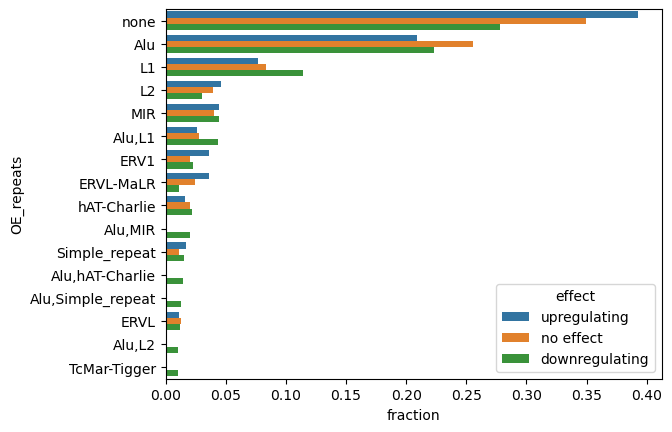

In [ ]:
sns.barplot(mpra_repeats
			#.filter(pl.col("effect")!="no effect")
			.select("effect",pl.col("OE_repeats"), pl.len().over("OE_repeats","effect").alias("fraction")/pl.len().over("effect")).unique().sort("fraction", descending=True)
			.filter(pl.col("fraction")>0.01).to_pandas(),
			x="fraction", y="OE_repeats", orient='h', hue="effect")

In [5]:
# Now ungrouping different classes

mpra_repeats_exploded = mpra_repeats.with_columns(
	pl.col("OE_repeats").str.split(",").alias("OE_repeats_exploded")
).explode("OE_repeats_exploded")

In [9]:
to_plot = mpra_repeats_exploded \
			.select("effect",pl.col("OE_repeats_exploded"), 
		   # Making sure to count unique interactions for fraction, since we can now have the same interaction in the dataset multiple times
		   pl.len().over("OE_repeats_exploded","effect").alias("fraction")/(pl.col("left_bin")+pl.col("right_bin")).n_unique().over("effect")).unique() \
		   .sort("fraction", descending=True) \
			.filter(pl.col("fraction")>0.001)

In [10]:
genome_repeats = pl.read_csv(cd+"results/manuscript_figures/revisions/repeat_elements/repeats_genome_fractions.tsv", separator="\t",
							new_columns=["OE_repeats_exploded", "fraction"], has_header=False) \
								.select(pl.lit("genome").alias("effect"), "OE_repeats_exploded", "fraction") \
									.join(to_plot.select("OE_repeats_exploded").unique(), on="OE_repeats_exploded", how="semi")

In [39]:
to_plot = pl.concat([to_plot, genome_repeats])

In [40]:
selected_repeats = to_plot.filter(pl.col("fraction") > 0.01).select("OE_repeats_exploded").unique()
to_plot = to_plot.join(selected_repeats, on="OE_repeats_exploded", how="semi")

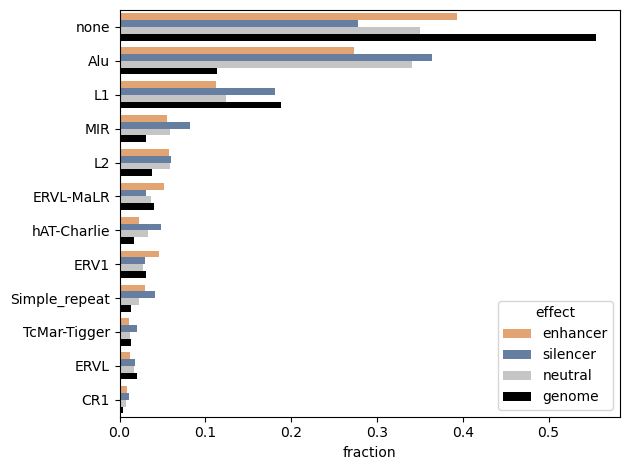

In [41]:
sns.barplot(to_plot
			.with_columns(effect = pl.when(pl.col("effect") == "upregulating").then(pl.lit("enhancer"))
											.when(pl.col("effect") == "downregulating").then(pl.lit("silencer"))
											.when(pl.col("effect") == "no effect").then(pl.lit("neutral"))
											.otherwise(pl.lit("genome"))).to_pandas(),
			x="fraction", y="OE_repeats_exploded", orient='h', hue="effect", palette=["#F4A261","#5D7CA8", "#c5c5c5", "black"])
plt.ylabel("")
plt.tight_layout()
plt.savefig(cd+"results/manuscript_figures/revisions/repeat_elements/repeat_family_enrichment_barplot.pdf", format="pdf")

In [27]:
genome_counts = pl.read_csv(cd+"results/manuscript_figures/revisions/repeat_elements/repeats_genome_counts.tsv", separator="\t",
							new_columns=["OE_repeats_exploded", "count"], has_header=False) \
								.select(
									pl.lit("genome").alias("effect"), "OE_repeats_exploded", 
									pl.col("count").cast(pl.UInt32)
								)

In [30]:
genome_total = pl.DataFrame({
	"effect": ["genome"],
	"total": [2911224348]
}).with_columns(
	pl.col("total").cast(pl.UInt32)
)

In [34]:
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact

repeat_counts = pl.concat([mpra_repeats_exploded.select("effect", "OE_repeats_exploded", pl.len().over("OE_repeats_exploded","effect").alias("count")).unique(),
						  genome_counts]).unique()
total_counts = pl.concat([mpra_repeats_exploded.select("effect",(pl.col("left_bin")+pl.col("right_bin")).n_unique().over("effect").alias("total")).unique(),
						  genome_total]).unique()
results = []
repeat_classes = repeat_counts["OE_repeats_exploded"].unique().to_list()

for repeat_class in repeat_classes:
	# counts: [overlaps, not overlaps]
	enhancers = [
		repeat_counts.filter((pl.col("effect") == "upregulating") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "upregulating") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "upregulating")["total"].item()
	]
	silencers = [
		repeat_counts.filter((pl.col("effect") == "downregulating") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "downregulating") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "downregulating")["total"].item()
	]
	other = [
		repeat_counts.filter((pl.col("effect") == "no effect") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "no effect") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "no effect")["total"].item()
	]
	genome = [
		repeat_counts.filter((pl.col("effect") == "genome") & (pl.col("OE_repeats_exploded") == repeat_class))["count"].item() if repeat_counts.filter((pl.col("effect") == "genome") & (pl.col("OE_repeats_exploded") == repeat_class)).height > 0 else 0,
		total_counts.filter(pl.col("effect") == "genome")["total"].item()
	]

	table = np.array([enhancers, silencers, other, genome]).T

	try:
		chi2, p, dof, expected = chi2_contingency(table)
	except Exception as e:
		chi2, p, dof, expected = np.nan, np.nan, np.nan, np.nan

	try:
		oddsratio, pAB = fisher_exact([[enhancers[0], enhancers[1]], [silencers[0], silencers[1]]])
		oddsratio, pAC = fisher_exact([[enhancers[0], enhancers[1]], [other[0], other[1]]])
		oddsratio, pBC = fisher_exact([[silencers[0], silencers[1]], [other[0], other[1]]])
		oddsratio, pAD = fisher_exact([[enhancers[0], enhancers[1]], [genome[0], genome[1]]])
		oddsratio, pBD = fisher_exact([[silencers[0], silencers[1]], [genome[0], genome[1]]])
		oddsratio, pCD = fisher_exact([[other[0], other[1]], [genome[0], genome[1]]])
	except Exception as e:
		pAB, pAC, pBC, pAD, pBD, pCD = np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

	results.append({
		"repeat_class": repeat_class,
		"chi2_p": p,
		"fisher_enh_vs_sil_p": pAB,
		"fisher_enh_vs_other_p": pAC,
		"fisher_sil_vs_other_p": pBC,
		"fisher_enh_vs_genome_p": pAD,
		"fisher_sil_vs_genome_p": pBD,
		"fisher_other_vs_genome_p": pCD
	})

# Display the dataframe in a more readable format in Jupyter
pl.Config.set_tbl_rows(50)
pl.DataFrame(results)
pl.DataFrame(results).write_csv(cd+"results/manuscript_figures/revisions/repeat_elements/repeat_family_enrichment_stats.tsv", separator="\t")
